In [ ]:
# __ROOTBOOT__ ensure project root on sys.path (auto-added; safe to keep)
import os as _os, sys as _sys
_r = _os.path.abspath('')
while _r != _os.path.dirname(_r) and not _os.path.exists(_os.path.join(_r, '.project_root')):
    _r = _os.path.dirname(_r)
if _os.path.exists(_os.path.join(_r, '.project_root')) and _r not in _sys.path:
    _sys.path.insert(0, _r)


# Seasonality v2 — Sections 2-11 (rebuild with fixes)

**Replaces** the earlier Sections 2-11. Append after Section 1 (data pull/validation).

**Fixes vs v1:**
1. T-bill yield baseline via BIL ETF (no more 0% cash)
2. Three evaluation modes per strategy: active-only, SPY-fill, BIL-fill
3. Per-strategy default-fill spec (literature-aligned)
4. Differential Sharpe vs SPY (signal quality on active days)
5. Slippage reduced for liquid ETF rotation (1bps for sectors, 5bps default)
6. Regime-conditional reporting (full / ex-COVID / ex-2022)
7. SPY-vol-matched benchmark for fair comparison
8. Sector seasonal redone with academic calendar (Jacobsen-Visaltanachoti)
9. Best-Six-Months MACD using month-end signals only

In [6]:
TICKERS_CORE = ["SPY", "TLT", "IWM", "IJR"]
TICKERS_SECTOR = ["XLE", "XLK", "XLY", "XLP", "XLU", "XLF", "XLI", "XLV", "XLB"]
TICKERS_ALL = TICKERS_CORE + TICKERS_SECTOR

import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from _shared.loaders_data import fetch_historical_data

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

OUT_DIR = Path("./output")
OUT_DIR.mkdir(exist_ok=True)
(OUT_DIR / "daily_equity").mkdir(exist_ok=True)
(OUT_DIR / "trades").mkdir(exist_ok=True)

START = datetime(2003, 1, 1)
END = datetime(2025, 5, 1)

# Reload validated prices if running fresh
px = pd.read_parquet(OUT_DIR / "prices_validated.parquet")
rets = px.pct_change()

SLIPPAGE_BPS = 5  # per side

## Section 2 — Setup, BIL data, helpers

In [7]:
# Pull BIL (1-3mo Treasury Bill ETF) — proxy for cash earning T-bill yield
from datetime import datetime
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from _shared.loaders_data import fetch_historical_data

raw_bil = fetch_historical_data(["BIL"], TimeFrame(1, TimeFrameUnit.Day), START, END)
bil_df = raw_bil["BIL"].copy()
bil_df.index = bil_df.index.tz_localize(None) if bil_df.index.tz is not None else bil_df.index

# Reindex BIL onto our business-day grid
px["BIL"] = bil_df["close"].reindex(px.index).ffill()
rets = px.pct_change()

print(f"BIL: {px['BIL'].first_valid_index().date()} → {px['BIL'].last_valid_index().date()}")
print(f"BIL annualized return: {(1 + rets['BIL'].mean())**252 - 1:.2%}")
print(f"BIL annualized vol:    {rets['BIL'].std() * np.sqrt(252):.2%}")

Fetching BIL...
  2,345 bars
BIL: 2016-01-04 → 2025-05-01
BIL annualized return: 1.82%
BIL annualized vol:    0.26%


In [8]:
# Helpers v2
OUT_DIR = Path("./output")
(OUT_DIR / "daily_equity").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "trades").mkdir(parents=True, exist_ok=True)

DEFAULT_SLIPPAGE_BPS = 5
SECTOR_SLIPPAGE_BPS = 1

def metrics_from_returns(daily_ret: pd.Series, name: str = "") -> dict:
    r = daily_ret.dropna()
    if len(r) < 2 or r.std() == 0:
        return {"name": name, "sharpe": 0, "cagr": 0, "vol": 0, "max_dd": 0, "calmar": 0, "n_days": len(r)}
    eq = (1 + r).cumprod()
    years = len(r) / 252
    cagr = eq.iloc[-1] ** (1 / years) - 1
    vol = r.std() * np.sqrt(252)
    sharpe = r.mean() / r.std() * np.sqrt(252)
    dd = (eq / eq.cummax() - 1).min()
    calmar = cagr / abs(dd) if dd < 0 else np.nan
    return {"name": name, "sharpe": sharpe, "cagr": cagr, "vol": vol, "max_dd": dd, "calmar": calmar, "n_days": len(r)}

def bootstrap_sharpe_pvalue(daily_ret: pd.Series, n_iter: int = 1000, seed: int = 42) -> float:
    r = daily_ret.dropna().values
    if len(r) < 30 or r.std() == 0:
        return np.nan
    rng = np.random.RandomState(seed)
    sharpes = np.empty(n_iter)
    for i in range(n_iter):
        sample = rng.choice(r, size=len(r), replace=True)
        sharpes[i] = sample.mean() / sample.std() * np.sqrt(252) if sample.std() > 0 else 0
    return (sharpes <= 0).mean()

def positions_to_returns(weights: pd.DataFrame, returns: pd.DataFrame, slippage_bps: float = DEFAULT_SLIPPAGE_BPS) -> pd.Series:
    w = weights.shift(1).fillna(0)
    gross = (w * returns).sum(axis=1)
    turnover = (weights - weights.shift(1)).abs().sum(axis=1).fillna(0)
    cost = turnover * (slippage_bps / 10000)
    return gross - cost

def positions_to_trades(weights: pd.DataFrame, prices: pd.DataFrame, name: str) -> pd.DataFrame:
    rows = []
    for inst in weights.columns:
        w = weights[inst].fillna(0)
        active = w != 0
        starts = active & ~active.shift(1, fill_value=False)
        ends = active & ~active.shift(-1, fill_value=False)
        for s, e in zip(w.index[starts], w.index[ends]):
            direction = "long" if w.loc[s] > 0 else "short"
            ep = prices.loc[s, inst]; xp = prices.loc[e, inst]
            ret_g = (xp/ep - 1) * (1 if direction == "long" else -1)
            rows.append({"entry_time": s, "exit_time": e, "direction": direction,
                         "instrument": inst, "entry_price": ep, "exit_price": xp,
                         "pct_return_gross": ret_g, "exit_reason": "calendar", "stop_price": np.nan})
    return pd.DataFrame(rows).sort_values("entry_time").reset_index(drop=True) if rows else pd.DataFrame()

print("Helpers loaded.")

Helpers loaded.


In [9]:
# Three-mode evaluation
def get_active_mask(weights: pd.DataFrame) -> pd.Series:
    """Days where strategy holds any non-zero position."""
    return (weights.abs().sum(axis=1) > 0)

def evaluate_three_modes(name: str, weights: pd.DataFrame, default_fill: str = "BIL",
                          slippage_bps: float = DEFAULT_SLIPPAGE_BPS) -> dict:
    """
    Returns dict with three equity curves and metrics:
    - active_only: strategy returns on active days only
    - default_fill: strategy + default_fill on idle days (BIL or SPY)
    - differential: (strategy_active − SPY_active) on active days only
    """
    # base strategy returns
    strat_ret = positions_to_returns(weights, rets[weights.columns], slippage_bps)
    active = get_active_mask(weights)
    
    # Mode A: active-only (NaN on idle days, then drop)
    active_only_ret = strat_ret.where(active.shift(1).fillna(False))
    
    # Mode B/C: default fill on idle days
    if default_fill == "BIL":
        idle_ret = rets["BIL"]
    elif default_fill == "SPY":
        idle_ret = rets["SPY"]
    elif default_fill == "NONE":
        # strategy is always invested, no idle days
        idle_ret = pd.Series(0.0, index=rets.index)
    else:
        raise ValueError(f"Unknown default_fill: {default_fill}")
    
    active_shifted = active.shift(1).fillna(False)
    filled_ret = strat_ret.where(active_shifted, idle_ret)
    
    # Differential: strategy vs SPY on active days only
    spy_active = rets["SPY"].where(active_shifted)
    diff_ret = (active_only_ret - spy_active).dropna()
    
    # Metrics
    m_active = metrics_from_returns(active_only_ret, f"{name}_active")
    m_filled = metrics_from_returns(filled_ret, f"{name}_{default_fill.lower()}fill")
    m_diff = metrics_from_returns(diff_ret, f"{name}_diff_vs_SPY")
    
    # P-value on the *filled* returns (full-period)
    p_filled = bootstrap_sharpe_pvalue(filled_ret)
    p_diff = bootstrap_sharpe_pvalue(diff_ret)
    
    # Active days count
    active_days = int(active.sum())
    pct_active = active_days / len(active) * 100
    
    # Save filled equity (canonical) for downstream
    eq_filled = (1 + filled_ret.fillna(0)).cumprod()
    eq_filled.to_frame("equity").to_csv(OUT_DIR / "daily_equity" / f"{name}_{default_fill.lower()}fill.csv")
    
    trades = positions_to_trades(weights, px, name)
    if len(trades) > 0:
        trades.to_csv(OUT_DIR / "trades" / f"{name}.csv", index=False)
    
    return {
        "name": name,
        "default_fill": default_fill,
        "active_days": active_days,
        "pct_active": pct_active,
        "n_trades": len(trades),
        "active": m_active,
        "filled": m_filled,
        "diff": m_diff,
        "p_filled": p_filled,
        "p_diff": p_diff,
        "strat_ret": strat_ret,
        "active_only_ret": active_only_ret,
        "filled_ret": filled_ret,
        "diff_ret": diff_ret,
        "eq_filled": eq_filled,
        "weights": weights,
    }

def print_three_mode(r: dict):
    print(f"  Active days:  {r['active_days']:>5} ({r['pct_active']:.0f}% of sample)")
    print(f"  Trades:       {r['n_trades']:>5}")
    print(f"  --- Active-only:    Sharpe {r['active']['sharpe']:>5.2f}  CAGR {r['active']['cagr']:>6.1%}  MaxDD {r['active']['max_dd']:>6.1%}")
    print(f"  --- {r['default_fill']:>3}-filled:   Sharpe {r['filled']['sharpe']:>5.2f}  CAGR {r['filled']['cagr']:>6.1%}  MaxDD {r['filled']['max_dd']:>6.1%}  p={r['p_filled']:.3f}")
    print(f"  --- Diff vs SPY:    Sharpe {r['diff']['sharpe']:>5.2f}  (active days only)              p={r['p_diff']:.3f}")

# SPY benchmark
spy_ret_full = rets["SPY"]
spy_eq_full = (1 + spy_ret_full.fillna(0)).cumprod()
spy_metrics = metrics_from_returns(spy_ret_full, "SPY_BH")
bil_metrics = metrics_from_returns(rets["BIL"], "BIL")
print("\nBenchmarks:")
print(f"  SPY: Sharpe {spy_metrics['sharpe']:.2f} | CAGR {spy_metrics['cagr']:.1%} | MaxDD {spy_metrics['max_dd']:.1%}")
print(f"  BIL: Sharpe {bil_metrics['sharpe']:.2f} | CAGR {bil_metrics['cagr']:.1%} | MaxDD {bil_metrics['max_dd']:.1%}")


Benchmarks:
  SPY: Sharpe 0.77 | CAGR 12.8% | MaxDD -33.8%
  BIL: Sharpe 6.83 | CAGR 1.8% | MaxDD -0.2%


## Section 3 — Sell in May / Halloween (BIL-defaulted)

In [11]:
winter_mask = px.index.month.isin([11, 12, 1, 2, 3, 4])

# v2: only the BIL-default version (cash variant) — TLT-defensive is a separate strategy with its own active days
w_sellmay = pd.DataFrame(0.0, index=px.index, columns=["SPY"])
w_sellmay.loc[winter_mask, "SPY"] = 1.0

# Variant: SPY-winter / TLT-summer (always invested → default_fill='NONE')
w_sellmay_tlt = pd.DataFrame(0.0, index=px.index, columns=["SPY", "TLT"])
w_sellmay_tlt.loc[winter_mask, "SPY"] = 1.0
w_sellmay_tlt.loc[~winter_mask, "TLT"] = 1.0

results = {}

print("=== sellmay (BIL-fill) ===")
r = evaluate_three_modes("sellmay", w_sellmay, default_fill="BIL")
print_three_mode(r); results["sellmay"] = r

print("\n=== sellmay_tlt (always invested, SPY↔TLT) ===")
r = evaluate_three_modes("sellmay_tlt", w_sellmay_tlt, default_fill="NONE")
print_three_mode(r); results["sellmay_tlt"] = r

=== sellmay (BIL-fill) ===
  Active days:   1250 (51% of sample)
  Trades:          10
  --- Active-only:    Sharpe  0.69  CAGR  12.7%  MaxDD -33.8%
  --- BIL-filled:   Sharpe  0.55  CAGR   7.2%  MaxDD -33.8%  p=0.031
  --- Diff vs SPY:    Sharpe -1.43  (active days only)              p=1.000

=== sellmay_tlt (always invested, SPY↔TLT) ===
  Active days:   2434 (100% of sample)
  Trades:          20
  --- Active-only:    Sharpe  0.37  CAGR   5.0%  MaxDD -35.6%
  --- NONE-filled:   Sharpe  0.37  CAGR   5.0%  MaxDD -35.6%  p=0.116
  --- Diff vs SPY:    Sharpe -0.49  (active days only)              p=0.944


## Section 4 — Best Six Months + MACD (month-end signals)

In [14]:
# Monthly close MACD on SPY (proper specification per Stock Trader's Almanac)
spy_monthly = px["SPY"].resample("M").last()
ema_fast_m = spy_monthly.ewm(span=12, adjust=False).mean()
ema_slow_m = spy_monthly.ewm(span=26, adjust=False).mean()
macd_m = ema_fast_m - ema_slow_m
signal_m = macd_m.ewm(span=9, adjust=False).mean()
macd_pos_monthly = (macd_m - signal_m) > 0

# Forward-fill monthly signal to daily
macd_pos_daily = macd_pos_monthly.reindex(px.index, method="ffill").fillna(False)

# State machine on month-end checkpoints only
in_position = pd.Series(False, index=px.index)
state = False
month_end_dates = px.resample("M").last().index
month_end_set = set(month_end_dates)

for i, dt in enumerate(px.index):
    m = dt.month
    # Check for state change only at month boundaries
    if dt in month_end_set or i == 0:
        macd_pos = bool(macd_pos_daily.iloc[i])
        if not state:
            if m in [10, 11, 12, 1, 2, 3, 4] and macd_pos:
                state = True
        else:
            if m in [4, 5, 6, 7, 8, 9] and not macd_pos:
                state = False
    in_position.iloc[i] = state

w_bsm = pd.DataFrame(0.0, index=px.index, columns=["SPY"])
w_bsm.loc[in_position, "SPY"] = 1.0

print("=== best_six_months_macd (month-end signals, BIL-fill) ===")
r = evaluate_three_modes("best_six_months_macd", w_bsm, default_fill="BIL")
print_three_mode(r); results["best_six_months_macd"] = r

=== best_six_months_macd (month-end signals, BIL-fill) ===
  Active days:   1715 (70% of sample)
  Trades:           4
  --- Active-only:    Sharpe  0.78  CAGR  13.0%  MaxDD -33.8%
  --- BIL-filled:   Sharpe  0.70  CAGR   9.7%  MaxDD -33.8%  p=0.014
  --- Diff vs SPY:    Sharpe -0.77  (active days only)              p=1.000


## Section 5 — Presidential Cycle (BIL-fill)

⚠️ Severe sample issue. Run for completeness only.

In [15]:
year_to_cycle = {2016: 4, 2017: 1, 2018: 2, 2019: 3, 2020: 4,
                  2021: 1, 2022: 2, 2023: 3, 2024: 4, 2025: 1}
cycle_yr = pd.Series([year_to_cycle.get(y, np.nan) for y in px.index.year], index=px.index)

# Long SPY in Y3, defensive in Y2, idle (BIL-fill) otherwise
w_pres = pd.DataFrame(0.0, index=px.index, columns=["SPY", "TLT"])
w_pres.loc[cycle_yr == 3, "SPY"] = 1.0
w_pres.loc[cycle_yr == 2, "TLT"] = 1.0

print("=== presidential_cycle (BIL-fill on Y1/Y4) ===")
r = evaluate_three_modes("presidential_cycle", w_pres, default_fill="BIL")
print_three_mode(r); results["presidential_cycle"] = r

=== presidential_cycle (BIL-fill on Y1/Y4) ===
  Active days:   1042 (43% of sample)
  Trades:           4
  --- Active-only:    Sharpe  0.30  CAGR   3.4%  MaxDD -35.2%
  --- BIL-filled:   Sharpe  0.28  CAGR   2.2%  MaxDD -35.1%  p=0.191
  --- Diff vs SPY:    Sharpe -0.17  (active days only)              p=0.642


## Section 6 — January Effect

- **6a:** IWM Jan, SPY rest of year (always invested, default_fill=NONE)
- **6b:** IWM Dec15-Feb15, SPY-fill on idle days (the claim is small-caps > large-caps in this window)
- **6c:** IJR Jan only, SPY-fill (same logic)

In [16]:
jan_mask = px.index.month == 1

# 6a: full-time invested
w_jan_a = pd.DataFrame(0.0, index=px.index, columns=["IWM", "SPY"])
w_jan_a.loc[jan_mask, "IWM"] = 1.0
w_jan_a.loc[~jan_mask, "SPY"] = 1.0

# 6b: IWM Dec15-Feb15, SPY-fill
is_dec_late = (px.index.month == 12) & (px.index.day >= 15)
is_feb_early = (px.index.month == 2) & (px.index.day <= 15)
small_cap_window = is_dec_late | jan_mask | is_feb_early
w_jan_b = pd.DataFrame(0.0, index=px.index, columns=["IWM"])
w_jan_b.loc[small_cap_window, "IWM"] = 1.0

# 6c: IJR Jan only, SPY-fill
w_jan_c = pd.DataFrame(0.0, index=px.index, columns=["IJR"])
w_jan_c.loc[jan_mask, "IJR"] = 1.0

print("=== january_iwm_jan_spy_rest (always invested) ===")
r = evaluate_three_modes("january_iwm_jan_spy_rest", w_jan_a, default_fill="NONE")
print_three_mode(r); results["january_iwm_jan_spy_rest"] = r

print("\n=== january_iwm_window (SPY-fill) ===")
r = evaluate_three_modes("january_iwm_window", w_jan_b, default_fill="SPY")
print_three_mode(r); results["january_iwm_window"] = r

print("\n=== january_ijr_only (SPY-fill) ===")
r = evaluate_three_modes("january_ijr_only", w_jan_c, default_fill="SPY")
print_three_mode(r); results["january_ijr_only"] = r

=== january_iwm_jan_spy_rest (always invested) ===
  Active days:   2434 (100% of sample)
  Trades:          20
  --- Active-only:    Sharpe  0.70  CAGR  11.6%  MaxDD -33.9%
  --- NONE-filled:   Sharpe  0.70  CAGR  11.6%  MaxDD -33.9%  p=0.016
  --- Diff vs SPY:    Sharpe -0.29  (active days only)              p=0.819

=== january_iwm_window (SPY-fill) ===
  Active days:    436 (18% of sample)
  Trades:          10
  --- Active-only:    Sharpe  0.87  CAGR  16.3%  MaxDD -15.0%
  --- SPY-filled:   Sharpe  0.72  CAGR  12.4%  MaxDD -34.3%  p=0.009
  --- Diff vs SPY:    Sharpe -0.11  (active days only)              p=0.554

=== january_ijr_only (SPY-fill) ===
  Active days:    221 (9% of sample)
  Trades:          10
  --- Active-only:    Sharpe  0.89  CAGR  16.2%  MaxDD -13.5%
  --- SPY-filled:   Sharpe  0.72  CAGR  12.1%  MaxDD -34.4%  p=0.007
  --- Diff vs SPY:    Sharpe -0.50  (active days only)              p=0.688


## Section 7 — Q4 Seasonality (BIL-fill)

In [17]:
q4_mask = px.index.month.isin([10, 11, 12])
w_q4 = pd.DataFrame(0.0, index=px.index, columns=["SPY"])
w_q4.loc[q4_mask, "SPY"] = 1.0

# TLT variant: always invested
w_q4_tlt = pd.DataFrame(0.0, index=px.index, columns=["SPY", "TLT"])
w_q4_tlt.loc[q4_mask, "SPY"] = 1.0
w_q4_tlt.loc[~q4_mask, "TLT"] = 1.0

print("=== q4_only (BIL-fill) ===")
r = evaluate_three_modes("q4_only", w_q4, default_fill="BIL")
print_three_mode(r); results["q4_only"] = r

print("\n=== q4_spy_tlt (always invested) ===")
r = evaluate_three_modes("q4_spy_tlt", w_q4_tlt, default_fill="NONE")
print_three_mode(r); results["q4_spy_tlt"] = r

=== q4_only (BIL-fill) ===
  Active days:    590 (24% of sample)
  Trades:           9
  --- Active-only:    Sharpe  1.35  CAGR  21.0%  MaxDD -19.6%
  --- BIL-filled:   Sharpe  0.85  CAGR   6.2%  MaxDD -19.2%  p=0.003
  --- Diff vs SPY:    Sharpe -1.97  (active days only)              p=1.000

=== q4_spy_tlt (always invested) ===
  Active days:   2434 (100% of sample)
  Trades:          19
  --- Active-only:    Sharpe  0.43  CAGR   5.4%  MaxDD -34.3%
  --- NONE-filled:   Sharpe  0.43  CAGR   5.4%  MaxDD -34.3%  p=0.074
  --- Diff vs SPY:    Sharpe -0.32  (active days only)              p=0.849


## Section 8 — Sector Seasonal (academic calendar)

Replaces the practitioner consensus with Jacobsen-Visaltanachoti significant pairs.
Key documented findings (2014):
- **Jan**: high returns in cyclicals (XLY, XLK, XLB)
- **Apr**: strong across most sectors except staples
- **May-Sep**: defensive sectors outperform (XLP, XLU, XLV)
- **Sep**: cyclical sectors particularly weak (avoid XLY, XLK, XLF)
- **Oct-Dec**: cyclicals recover (XLY, XLK, XLI)

**Two versions:**
- **8a:** EW basket of historically strong sectors per month (long-only)
- **8b:** Same but BIL-fill on months where no significant outperformance documented

In [18]:
# Academic calendar: equal-weight basket per month, BIL when no clear signal
# Based on Jacobsen-Visaltanachoti significant t-stats
month_to_basket = {
    1:  ["XLY", "XLK", "XLB"],     # Jan: cyclicals
    2:  ["XLK", "XLY"],             # Feb: tech + disc
    3:  ["XLB", "XLE"],             # Mar: materials, energy
    4:  ["XLY", "XLK", "XLI", "XLB"], # Apr: broad cyclical strength
    5:  ["XLU", "XLV"],             # May: defensives start
    6:  ["XLP", "XLV", "XLU"],      # Jun: full defensive
    7:  ["XLV", "XLP"],             # Jul: defensive
    8:  ["XLP", "XLU"],             # Aug: defensive
    9:  None,                        # Sep: BIL fill (cyclicals weak, defensives weak)
    10: ["XLK", "XLY", "XLI"],      # Oct: cyclicals recover
    11: ["XLY", "XLK"],             # Nov: holiday + tech
    12: ["XLY", "XLK", "XLI"],      # Dec: full cyclicals
}

all_sectors = list(set(s for v in month_to_basket.values() if v for s in v))
w_seasonal = pd.DataFrame(0.0, index=px.index, columns=all_sectors)
for m_num in range(1, 13):
    basket = month_to_basket[m_num]
    if basket is None:
        continue
    mask = px.index.month == m_num
    weight_each = 1.0 / len(basket)
    for s in basket:
        w_seasonal.loc[mask, s] = weight_each

print("=== sector_seasonal_academic (BIL-fill on Sep, 1bps slip) ===")
r = evaluate_three_modes("sector_seasonal_academic", w_seasonal, default_fill="BIL",
                          slippage_bps=SECTOR_SLIPPAGE_BPS)
print_three_mode(r); results["sector_seasonal_academic"] = r

=== sector_seasonal_academic (BIL-fill on Sep, 1bps slip) ===
  Active days:   2242 (92% of sample)
  Trades:         136
  --- Active-only:    Sharpe  0.71  CAGR  13.2%  MaxDD -45.5%
  --- BIL-filled:   Sharpe  0.69  CAGR  12.2%  MaxDD -45.5%  p=0.011
  --- Diff vs SPY:    Sharpe -0.20  (active days only)              p=0.738


## Section 9 — Month-of-Year Tilt (Walk-Forward, EW top-3)

v2 changes:
- Hold **top 3 sectors** for that month (not just top 1) — reduces single-sector concentration
- 1 bps slippage (liquid ETFs)
- Always invested (no fill needed)

In [20]:
sector_etfs = TICKERS_SECTOR
sector_monthly_ret = px[sector_etfs].resample("M").last().pct_change()

min_train_months = 36
monthly_ends = sector_monthly_ret.index
TOP_K = 3

target_basket_by_month = {}
for i, month_end in enumerate(monthly_ends):
    if i < min_train_months:
        continue
    next_month = (month_end + pd.offsets.MonthEnd(1)).month
    train = sector_monthly_ret.iloc[:i+1]
    same_cal = train[train.index.month == next_month]
    if len(same_cal) < 3:
        continue
    avg = same_cal.mean()
    top_k = avg.nlargest(TOP_K).index.tolist()
    target_basket_by_month[month_end] = top_k

w_moy = pd.DataFrame(0.0, index=px.index, columns=sector_etfs)
for month_end, basket in target_basket_by_month.items():
    next_start = month_end + pd.offsets.MonthBegin(1)
    next_end = next_start + pd.offsets.MonthEnd(0)
    mask = (px.index >= next_start) & (px.index <= next_end)
    weight_each = 1.0 / len(basket)
    for s in basket:
        w_moy.loc[mask, s] = weight_each

print(f"=== month_of_year_tilt_walkforward (top-{TOP_K} EW, 1bps slip) ===")
r = evaluate_three_modes("month_of_year_tilt", w_moy, default_fill="NONE",
                          slippage_bps=SECTOR_SLIPPAGE_BPS)
print_three_mode(r); results["month_of_year_tilt"] = r

=== month_of_year_tilt_walkforward (top-3 EW, 1bps slip) ===
  Active days:   1630 (67% of sample)
  Trades:         167
  --- Active-only:    Sharpe  0.46  CAGR   8.0%  MaxDD -40.6%
  --- NONE-filled:   Sharpe  0.38  CAGR   5.3%  MaxDD -40.6%  p=0.119
  --- Diff vs SPY:    Sharpe -0.53  (active days only)              p=0.911


## Section 10 — Skip September (BIL-fill)

In [21]:
sep_mask = px.index.month == 9
w_skipsep = pd.DataFrame(0.0, index=px.index, columns=["SPY"])
w_skipsep.loc[~sep_mask, "SPY"] = 1.0

w_skipsep_tlt = pd.DataFrame(0.0, index=px.index, columns=["SPY", "TLT"])
w_skipsep_tlt.loc[~sep_mask, "SPY"] = 1.0
w_skipsep_tlt.loc[sep_mask, "TLT"] = 1.0

print("=== skip_september (BIL-fill in Sep) ===")
r = evaluate_three_modes("skip_september", w_skipsep, default_fill="BIL")
print_three_mode(r); results["skip_september"] = r

print("\n=== skip_september_tlt (TLT in Sep, always invested) ===")
r = evaluate_three_modes("skip_september_tlt", w_skipsep_tlt, default_fill="NONE")
print_three_mode(r); results["skip_september_tlt"] = r

=== skip_september (BIL-fill in Sep) ===
  Active days:   2242 (92% of sample)
  Trades:          10
  --- Active-only:    Sharpe  0.91  CAGR  15.9%  MaxDD -33.8%
  --- BIL-filled:   Sharpe  0.88  CAGR  14.7%  MaxDD -33.8%  p=0.003
  --- Diff vs SPY:    Sharpe -1.01  (active days only)              p=1.000

=== skip_september_tlt (TLT in Sep, always invested) ===
  Active days:   2434 (100% of sample)
  Trades:          19
  --- Active-only:    Sharpe  0.71  CAGR  11.7%  MaxDD -33.8%
  --- NONE-filled:   Sharpe  0.71  CAGR  11.7%  MaxDD -33.8%  p=0.013
  --- Diff vs SPY:    Sharpe -0.18  (active days only)              p=0.712


## Section 11 — Cross-Strategy Comparison + Regime Conditioning

In [22]:
# Master summary: filled-mode metrics + diff vs SPY + p-values
rows = []
for name, r in results.items():
    rows.append({
        "strategy": name,
        "fill": r["default_fill"],
        "sharpe_filled": r["filled"]["sharpe"],
        "cagr_filled": r["filled"]["cagr"],
        "maxdd_filled": r["filled"]["max_dd"],
        "sharpe_active": r["active"]["sharpe"],
        "sharpe_diff": r["diff"]["sharpe"],
        "p_filled": r["p_filled"],
        "p_diff": r["p_diff"],
        "pct_active": r["pct_active"],
        "n_trades": r["n_trades"],
    })

summary = pd.DataFrame(rows).set_index("strategy")
summary.loc["SPY_BH"] = {"fill": "-", "sharpe_filled": spy_metrics["sharpe"], "cagr_filled": spy_metrics["cagr"],
                          "maxdd_filled": spy_metrics["max_dd"], "sharpe_active": np.nan, "sharpe_diff": np.nan,
                          "p_filled": np.nan, "p_diff": np.nan, "pct_active": 100, "n_trades": np.nan}
summary.loc["BIL"] = {"fill": "-", "sharpe_filled": bil_metrics["sharpe"], "cagr_filled": bil_metrics["cagr"],
                       "maxdd_filled": bil_metrics["max_dd"], "sharpe_active": np.nan, "sharpe_diff": np.nan,
                       "p_filled": np.nan, "p_diff": np.nan, "pct_active": 100, "n_trades": np.nan}
summary = summary.sort_values("sharpe_filled", ascending=False)

disp = summary.copy()
for col in ["sharpe_filled", "sharpe_active", "sharpe_diff"]:
    disp[col] = disp[col].map(lambda x: f"{x:.2f}" if pd.notna(x) else "")
for col in ["cagr_filled", "maxdd_filled"]:
    disp[col] = disp[col].map(lambda x: f"{x:.1%}" if pd.notna(x) else "")
for col in ["p_filled", "p_diff"]:
    disp[col] = disp[col].map(lambda x: f"{x:.3f}" if pd.notna(x) else "")
disp["pct_active"] = disp["pct_active"].map(lambda x: f"{x:.0f}%")
print("=" * 130)
print("FULL SAMPLE")
print("=" * 130)
print(disp.to_string())

FULL SAMPLE
                          fill sharpe_filled cagr_filled maxdd_filled sharpe_active sharpe_diff p_filled p_diff pct_active  n_trades
strategy                                                                                                                            
BIL                          -          6.83        1.8%        -0.2%                                                 100%       NaN
skip_september             BIL          0.88       14.7%       -33.8%          0.91       -1.01    0.003  1.000        92%      10.0
q4_only                    BIL          0.85        6.2%       -19.2%          1.35       -1.97    0.003  1.000        24%       9.0
SPY_BH                       -          0.77       12.8%       -33.8%                                                 100%       NaN
january_iwm_window         SPY          0.72       12.4%       -34.3%          0.87       -0.11    0.009  0.554        18%      10.0
january_ijr_only           SPY          0.72       12.1% 

In [23]:
# Regime-conditional Sharpe of the filled returns
covid_window = (px.index >= "2020-02-15") & (px.index <= "2020-08-31")
bear_2022 = (px.index >= "2022-01-01") & (px.index <= "2022-12-31")

def sharpe_subperiod(daily_ret: pd.Series, mask: pd.Series) -> float:
    r = daily_ret[~mask].dropna()
    if len(r) < 30 or r.std() == 0:
        return np.nan
    return r.mean() / r.std() * np.sqrt(252)

regime_rows = []
for name, r in results.items():
    fr = r["filled_ret"]
    regime_rows.append({
        "strategy": name,
        "sharpe_full": r["filled"]["sharpe"],
        "sharpe_ex_covid": sharpe_subperiod(fr, covid_window),
        "sharpe_ex_2022": sharpe_subperiod(fr, bear_2022),
        "sharpe_ex_both": sharpe_subperiod(fr, covid_window | bear_2022),
    })
regime_df = pd.DataFrame(regime_rows).set_index("strategy").sort_values("sharpe_full", ascending=False)

# Add SPY for context
regime_df.loc["SPY_BH"] = {
    "sharpe_full": spy_metrics["sharpe"],
    "sharpe_ex_covid": sharpe_subperiod(spy_ret_full, covid_window),
    "sharpe_ex_2022": sharpe_subperiod(spy_ret_full, bear_2022),
    "sharpe_ex_both": sharpe_subperiod(spy_ret_full, covid_window | bear_2022),
}

disp_r = regime_df.copy()
for c in disp_r.columns:
    disp_r[c] = disp_r[c].map(lambda x: f"{x:.2f}" if pd.notna(x) else "")
print("=" * 100)
print("REGIME-CONDITIONAL SHARPE (filled returns)")
print("=" * 100)
print(disp_r.to_string())

REGIME-CONDITIONAL SHARPE (filled returns)
                         sharpe_full sharpe_ex_covid sharpe_ex_2022 sharpe_ex_both
strategy                                                                          
skip_september                  0.88            1.03           1.10           1.37
q4_only                         0.85            0.87           0.95           0.97
january_iwm_window              0.72            0.81           0.97           1.15
january_ijr_only                0.72            0.82           0.98           1.18
skip_september_tlt              0.71            0.81           0.94           1.14
january_iwm_jan_spy_rest        0.70            0.78           0.97           1.17
best_six_months_macd            0.70            0.99           0.87           1.28
sector_seasonal_academic        0.69            0.98           0.82           1.23
sellmay                         0.55            0.85           0.72           1.14
q4_spy_tlt                      0.43        

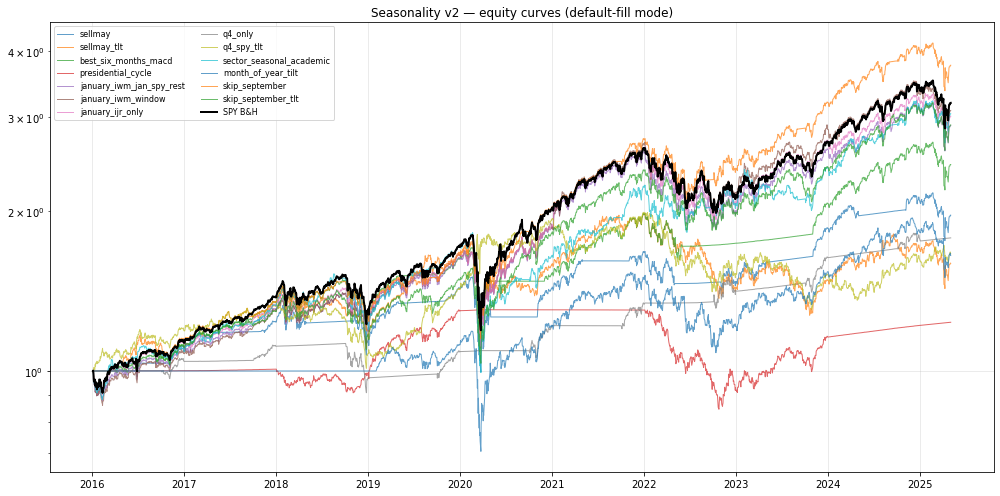

In [24]:
# Equity curves comparison
fig, ax = plt.subplots(figsize=(14, 7))
for name, r in results.items():
    eq = r["eq_filled"]
    ax.plot(np.asarray(eq.index), np.asarray(eq.values), lw=1.0, alpha=0.7, label=name)
ax.plot(np.asarray(spy_eq_full.index), np.asarray(spy_eq_full.values), lw=2.0, color="black", label="SPY B&H")
ax.set_yscale("log")
ax.set_title("Seasonality v2 — equity curves (default-fill mode)")
ax.legend(fontsize=8, ncol=2, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

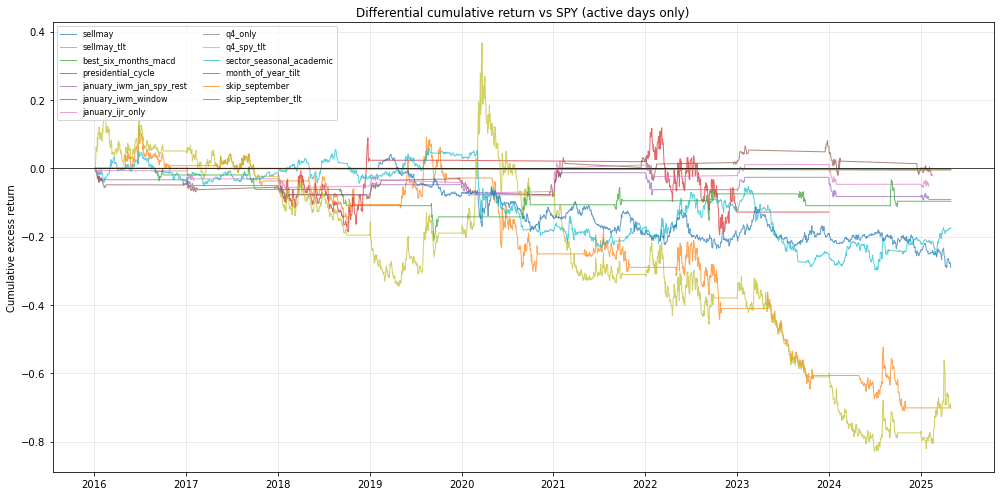

In [25]:
# Differential equity curves: strategy minus SPY (cumulative on active days)
fig, ax = plt.subplots(figsize=(14, 7))
for name, r in results.items():
    if r["diff"]["n_days"] < 30:
        continue
    diff = r["diff_ret"].dropna()
    diff_eq = diff.cumsum()  # additive cumulative for excess returns
    ax.plot(np.asarray(diff_eq.index), np.asarray(diff_eq.values), lw=1.0, alpha=0.7, label=name)
ax.axhline(0, color="black", lw=0.7)
ax.set_title("Differential cumulative return vs SPY (active days only)")
ax.set_ylabel("Cumulative excess return")
ax.legend(fontsize=8, ncol=2, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# Correlation matrix on filled returns
ret_df = pd.DataFrame({name: r["filled_ret"] for name, r in results.items()})
ret_df["SPY_BH"] = spy_ret_full
ret_df["BIL"] = rets["BIL"]
corr = ret_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(corr.iloc[i,j]) > 0.5 else "black")
plt.colorbar(im, ax=ax, fraction=0.04)
ax.set_title("Daily-return correlation matrix (filled-mode)")
plt.tight_layout(); plt.show()

In [ ]:
# Save
import json
summary.to_csv(OUT_DIR / "seasonality_v2_summary.csv")
regime_df.to_csv(OUT_DIR / "seasonality_v2_regime.csv")

out = {}
for name, r in results.items():
    out[name] = {
        "default_fill": r["default_fill"],
        "active_days": r["active_days"],
        "pct_active": r["pct_active"],
        "n_trades": r["n_trades"],
        "active_sharpe": float(r["active"]["sharpe"]),
        "filled_sharpe": float(r["filled"]["sharpe"]),
        "diff_sharpe": float(r["diff"]["sharpe"]),
        "filled_cagr": float(r["filled"]["cagr"]),
        "filled_maxdd": float(r["filled"]["max_dd"]),
        "p_filled": float(r["p_filled"]) if pd.notna(r["p_filled"]) else None,
        "p_diff": float(r["p_diff"]) if pd.notna(r["p_diff"]) else None,
    }
with open(OUT_DIR / "seasonality_v2_summary.json", "w") as f:
    json.dump(out, f, indent=2)
print("Saved v2 outputs.")

---

## How to read v2 results

**`sharpe_active`** — Sharpe on active-period days only. Best test of whether the timing rule itself adds value, isolated from idle-day noise.

**`sharpe_filled`** — Sharpe of the deployable strategy (active + idle filled). This is what your portfolio would actually earn.

**`sharpe_diff`** — Sharpe of (strategy − SPY) on active days only. Cleanest test: did the strategy beat just-being-long-SPY when it was active? Positive = active days picked well; negative = active days were worse than random.

**`p_diff`** — p-value of the diff Sharpe. If p_diff > 0.5 the strategy is actively *worse* than SPY on its active days (timing rule is anti-signal).

**Regime table** — if Sharpe collapses when you exclude COVID and 2022, the strategy isn't a real seasonal effect, it's just "hold equity in years equity went up."